In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
oil = pd.read_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/oil_prices_cleaned.csv", index_col=0, parse_dates=True)
oil.columns = ["Price", "Year", "Month", "Day", "MA_7", "MA_30", "MA_90", "Daily_Change", "Pct_Change"]

print(oil.shape)
print(oil.describe())

(4082, 9)
             Price         Year        Month          Day         MA_7  \
count  4082.000000  4082.000000  4082.000000  4082.000000  4076.000000   
mean     66.637004  2020.096766     6.445860     3.000245    66.632056   
std      17.541054     3.225525     3.476689     2.000061    17.489332   
min      19.330000  2015.000000     1.000000     0.000000    20.762857   
25%      53.874999  2017.000000     3.000000     1.000000    53.889286   
50%      66.250000  2020.000000     6.000000     3.000000    66.156428   
75%      77.620003  2023.000000     9.000000     5.000000    77.726428   
max     127.980003  2026.000000    12.000000     6.000000   122.302858   

             MA_30        MA_90  Daily_Change   Pct_Change  
count  4053.000000  3993.000000   4081.000000  4081.000000  
mean     66.664665    66.753941      0.008888     0.033584  
std      17.359394    17.065563      1.313870     2.059645  
min      26.230333    30.307000    -16.840004   -24.403597  
25%      53.713000

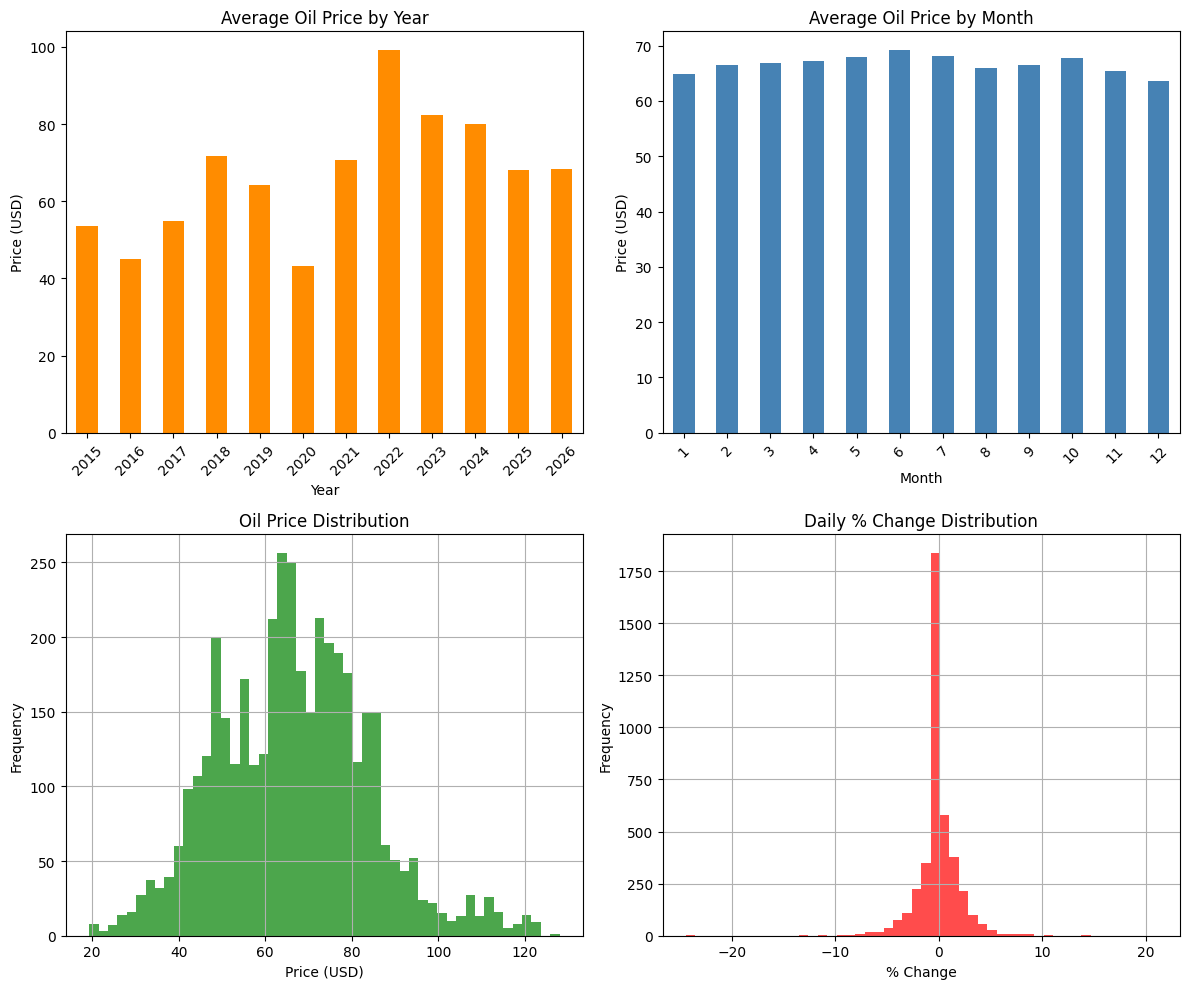

In [2]:
# Average oil price by year
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
oil.groupby("Year")["Price"].mean().plot(kind="bar", color="darkorange")
plt.title("Average Oil Price by Year")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)

# Average oil price by month
plt.subplot(2, 2, 2)
oil.groupby("Month")["Price"].mean().plot(kind="bar", color="steelblue")
plt.title("Average Oil Price by Month")
plt.xlabel("Month")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)

# Price distribution
plt.subplot(2, 2, 3)
oil["Price"].hist(bins=50, color="green", alpha=0.7)
plt.title("Oil Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

# Daily percentage change distribution
plt.subplot(2, 2, 4)
oil["Pct_Change"].hist(bins=50, color="red", alpha=0.7)
plt.title("Daily % Change Distribution")
plt.xlabel("% Change")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

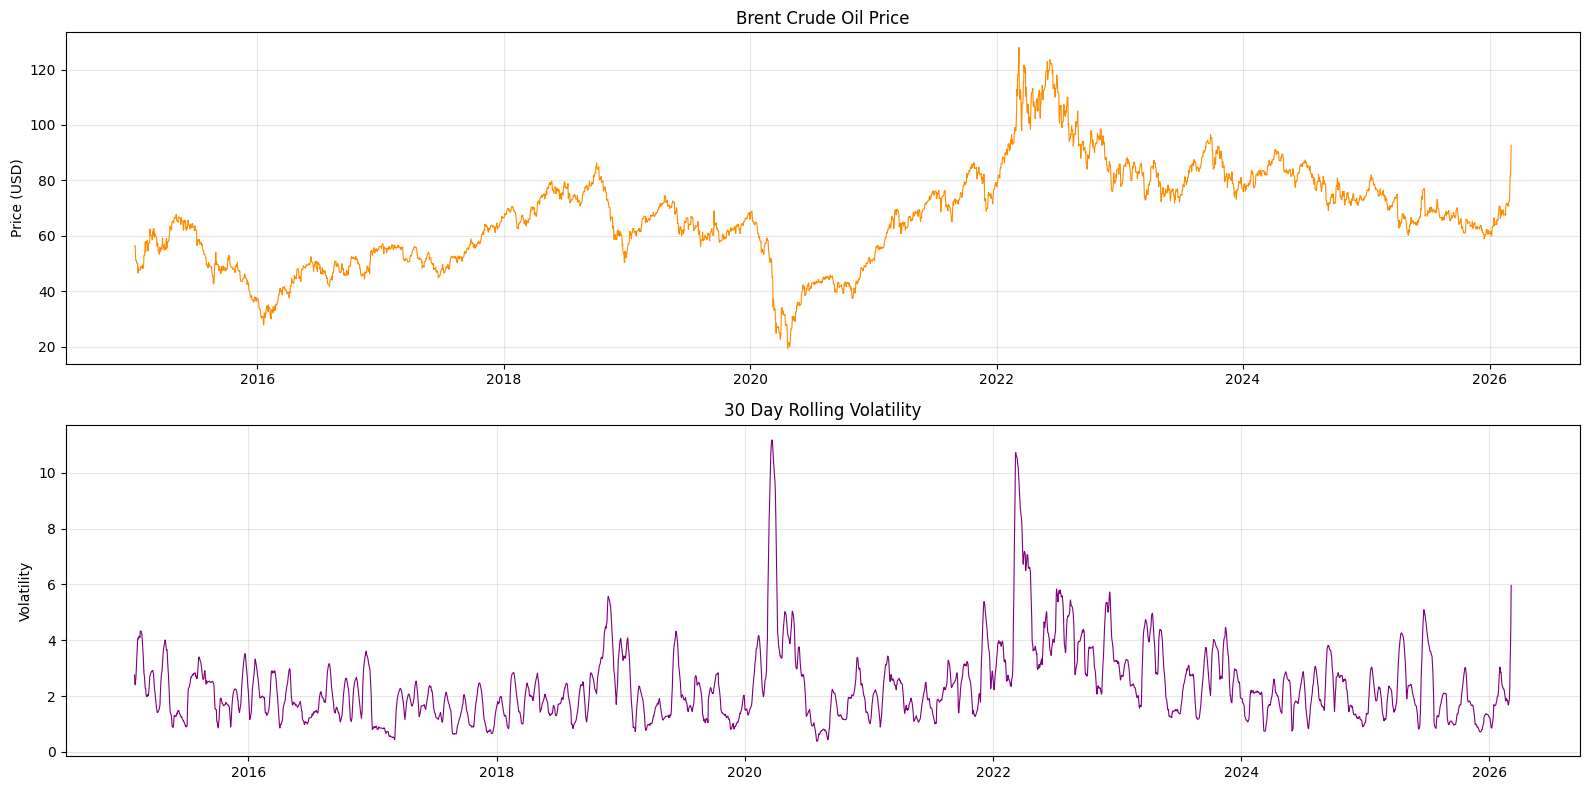

In [3]:
# Calculate rolling volatility (30 day standard deviation)
oil["Volatility_30"] = oil["Price"].rolling(window=30).std()

plt.figure(figsize=(16, 8))

# Price
plt.subplot(2, 1, 1)
plt.plot(oil.index, oil["Price"], color="darkorange", linewidth=0.8)
plt.title("Brent Crude Oil Price", fontsize=12)
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)

# Volatility
plt.subplot(2, 1, 2)
plt.plot(oil.index, oil["Volatility_30"], color="purple", linewidth=0.8)
plt.title("30 Day Rolling Volatility", fontsize=12)
plt.ylabel("Volatility")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#When volatility is high — our forecasting model will find it harder to predict accurately. The market is behaving emotionally and irrationally.
